# Lecture : Shallow Graph Feature Learning

## Lab 01 : DeepWalk - Solution

### Xavier Bresson, Guoji Fu   

Perozzi, Al-Rfou, Skiena, DeepWalk: Online learning of social representations, 2014  
https://arxiv.org/pdf/1403.6652.pdf

Notebook goals :<br>
• Design a random walk extractor <br>
• Implement the deepwalk technique <br>
• Compare visually the deepwalk embedding with networkx visualization <br>


In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2025_codes/codes/07_Shallow_Learning'
    print(path_to_file)
    # change current path to the folder containing "path_to_file"
    os.chdir(path_to_file)
    !pwd
    !pip install rdkit==2023.09.6 # Install RDKit
    !pip install dgl==1.0.0 # Install DGL


In [2]:
# Libraries
import pickle
import sys; sys.path.insert(0, 'lib/')
from lib.utils import Molecule
from rdkit import Chem
import torch
import torch.nn as nn
import networkx as nx
import matplotlib.pyplot as plt
import random
from lib.utils import compute_ncut

In [3]:
import os, torch
print(os.environ.get("KMP_DUPLICATE_LIB_OK"))
print(os.environ.get("OMP_NUM_THREADS"))
print(torch.__version__)

TRUE
4
2.1.2+cpu


## Load dataset and select one molecule

Loading data
23
tensor([0, 5, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 4, 0, 0, 0, 2])
tensor([ 0,  0,  1,  2,  3,  4,  0,  0,  5,  6,  7,  8,  9, 10,  1, 11,  1, 12,
         0, 13, 14, 15,  2])
tensor([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
        [0, 0, 0, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       

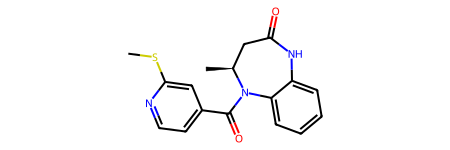

In [4]:
print('Loading data')
data_folder_pytorch = 'datasets/ZINC_pytorch/'
with open(data_folder_pytorch+"train_pytorch.pkl","rb") as f:
    dataset=pickle.load(f)

# Select one molecule
idx = 12
mol: Molecule = dataset[idx]
print(mol.num_atom)
print(mol.atom_type) # Atom type of each atom in the molecule
print(mol.atom_type_pe) # Positional encoding of each atom in the molecule
print(mol.bond_type) # NxN matrix for Bond type between atoms. 0 means no bond, 1 means single bond, etc.
print(mol.bag_of_atoms) # How many of each atom type in the molecule
print(mol.logP_SA_cycle_normalized) # Target property to predict. No need to know what this means. 
print(mol.smile) # Textual representation of the molecule
Chem.MolFromSmiles(mol.smile) # Visualize the molecule

## Exercise 1 : Design a random walk extractor

### Question 1.1 : Implement a class that generates a random walk path.

Hints:
- Sample the next node from the RW probability `prob_j = sample(RW[i,:]`.
- Use Bernoulli sampling with function `torch.distributions.Categorical(prob).sample()`.


In [5]:
class sample_RW_path:

    def __init__(self, num_steps: int, RW: torch.Tensor):
        self.num_steps = num_steps # number of steps in the random walk
        self.RW = RW # random walk matrix
        self.num_nodes = RW.size(0) # number of nodes in the graph

    def sample_walk(self, idx_start: int) -> torch.Tensor:
        """
        Generates a single random walk path of length self.num_steps starting from node idx_start.
        """
        idx = torch.tensor(idx_start).long() # current node at step t of the random walk. Initialize the walk to start from nodes[idx_start]
        RWpath = [idx] # random walk path
        for _ in range(self.num_steps - 1):
            ########################################
            # YOUR CODE START
            # sample the next node from the RW probability prob_j = sample(RW[i,:]) where i is the current node
            # use Bernoulli sampling with torch.distributions.Categorical(prob).sample()
            ########################################

            idx = torch.distributions.Categorical(self.RW[idx, :]).sample()

            ########################################
            # YOUR CODE END
            ########################################

            RWpath.append(idx) # append sampled node to the path
        RWpath = torch.stack(RWpath).flatten() # path format = torch.tensor([idx_1, idx_2, ..., idx_num_steps])
        return RWpath

### Question 1.2 : Use the previously defined function to sample a random walk path.

Hints:
- Step 1: Compute the RW operator with $RW = D^{-1}A$.
- Step 2: Choose the number of RW steps.
- Step 3: Use `sample_RW_path()` to instantiate a RW class.
- Step 4: Apply `sample_walk()` to extract a RW path.
  

In [6]:
A = (mol.bond_type > 0).float() # (Binary) Adjacency matrix. A 0 in mol.bond_type means no bond between atoms
D = A.sum(dim=0) # Degree vector. Sums across rows to get degree of each node

########################################
# YOUR CODE START
########################################

# Step 1: # Compute the RW operator
# Compute the inverse degree matrix
Dinv = (D ** (-1)).diag()

# Compute RW matrix
RW = torch.mm(Dinv, A) # RW matrix

# Step 2: choose the number of RW steps
num_RW_steps = 4 # QM9

# Step 3: instantiate RW class
generator = sample_RW_path(num_RW_steps, RW)

# Step 4: sample RW path starting with node index=7
walk = generator.sample_walk(7)

########################################
# YOUR CODE END
########################################

print('RW:', walk)


RW: tensor([ 7,  8,  9, 10])


### Visualise the sampled RW path

In [7]:
A_nx = nx.from_numpy_array(A.numpy())
C = compute_ncut(A.long(), 4)

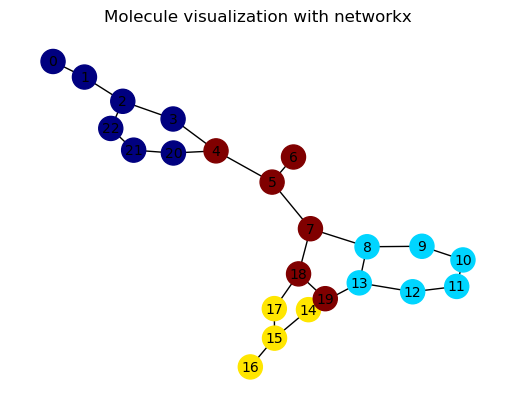

In [8]:
# Check visually RW path correctness
fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(A_nx, ax=ax, node_color=C, cmap='jet', with_labels=True, font_size=10) # visualise node indexes
ax.title.set_text('Molecule visualization with networkx')
plt.show()

## Exercise 2 : Implement the DeepWalk paper

### Question 2.1 : Implement a DeepWalk network class and apply it to molecular graphs.

Instructions:
- Step 1: Extract the embedding $h_i$ for node i. You can use the `.unsqueeze()` method.
- Step 2: Extract the embeddings $h_j$ for nodes j in the RW. You may use the `.transpose()` method.
- Step 3: Extract the embeddings $h_k$ for nodes k not in the RW. 


In [9]:
class deepwalk_net(nn.Module):

    def __init__(self, num_nodes, hidden_dim, num_negative):
        super(deepwalk_net, self).__init__()
        print(num_nodes, hidden_dim)
        self.num_nodes = num_nodes
        self.num_negative = num_negative
        self.node_embedding = nn.Embedding(num_nodes, hidden_dim) # (num_nodes x hidden_dim) embedding/lookup matrix

    def forward(self, walk):
        walk_list = walk.tolist() # list nodes in RW
        node_list = list(range(self.num_nodes)) # list all nodes
        list_negative = torch.tensor(list(set(node_list) - set(walk_list))) # all possible negative samples
        loss = []
        for i in walk: # loop over all nodes in RW
                       # node i that must predict all other nodes j in RW

            ########################################
            # YOUR CODE START
            ########################################

            # positive samples
            # Step1: extract embedding hi of node i
            hi = self.node_embedding(i).unsqueeze(0) # embed node i

            # Step 2: extract embedding hj of nodes j in RW
            j = torch.tensor(list(set(walk_list) - set([i.detach().item()]))) # all other nodes j in RW
            # hj.size()=(num_RW_steps-1,hidden_dim), you may use ".transpose()"
            hj = self.node_embedding(j).transpose(1, 0) # embed nodes j

            # negative samples : select randomly "num_negative" nodes which are not in the RW path
            list_negative = list_negative[torch.randperm(list_negative.size(0))][:self.num_negative] # select randomly "num_negative" negative samples

            # Step 3: extract embedding hk of nodes k not in RW
            # hk.size()=(num_negative,hidden_dim), you may use ".transpose()"
            ### YOUR CODE HERE
            hk = self.node_embedding(list_negative).transpose(1, 0) # embed negative nodes k

            ########################################
            # YOUR CODE END
            ########################################

            # compute loss
            loss_i = -(torch.log(torch.sigmoid(torch.mm(hi, hj))).sum() - 0.25*torch.log(torch.sigmoid(torch.mm(hi,hk))).sum())
            loss.append(loss_i)
        loss = torch.stack(loss).mean()
        return loss


### Question 2.2 : Instantiate a DeepWalk network

Instructions:
- Select the number of negative samples and use the `deepwalk()` function to instantiate the network.
- Evaluate and compare the performance of DeepWalk networks using different numbers of negative samples.


In [10]:
num_nodes = A.size(0)

########################################
# YOUR CODE START
########################################
embedding_dim = 2
num_negative = num_RW_steps // 4 # number of negative samples to draw for each node
my_network = deepwalk_net(num_nodes, embedding_dim, num_negative)

########################################
# YOUR CODE END
########################################

print(my_network)


23 2
deepwalk_net(
  (node_embedding): Embedding(23, 2)
)


### Train the deepwalk network

In [11]:
# Train the network
optimizer = torch.optim.Adam(my_network.parameters() , lr=0.001)
for iter in range(300):
    loss_epoch = 0.0
    for idx in torch.randperm(num_nodes).tolist(): # shuffle ordering of nodes
        walk = generator.sample_walk(idx)
        loss = my_network(walk)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_epoch += loss.detach()
        with torch.no_grad():
            # centering the embedding coordinates
            # helps optimization by reducing one degree of freedom
            my_network.node_embedding.weight.sub_(my_network.node_embedding.weight.mean(dim=0))
    # plot the loss value
    if not iter%10:
        print(iter, loss_epoch/num_nodes)

0 tensor(2.1466)
10 tensor(1.5628)
20 tensor(1.4747)
30 tensor(1.7537)
40 tensor(1.4127)
50 tensor(1.6158)
60 tensor(1.2332)
70 tensor(1.1362)
80 tensor(0.9671)
90 tensor(1.0190)
100 tensor(0.9828)
110 tensor(0.8300)
120 tensor(0.7068)
130 tensor(0.7000)
140 tensor(0.6923)
150 tensor(0.3532)
160 tensor(0.3314)
170 tensor(0.4891)
180 tensor(0.1716)
190 tensor(0.3820)
200 tensor(0.2369)
210 tensor(0.1521)
220 tensor(-0.1808)
230 tensor(-0.0550)
240 tensor(0.1670)
250 tensor(-0.0064)
260 tensor(0.3354)
270 tensor(-0.1350)
280 tensor(-0.2849)
290 tensor(0.0706)


### Visualize the node embeddings in 2D

tensor([[ 1.9950e+00, -5.0739e-01],
        [ 1.1058e+00, -1.6569e+00],
        [ 1.1929e+00, -2.7246e+00],
        [-3.7225e-01, -1.6574e+00],
        [ 1.4026e+00, -1.9739e+00],
        [ 1.5307e+00, -7.7190e-01],
        [ 2.7457e+00, -9.0341e-01],
        [ 7.4024e-01, -1.1994e-01],
        [ 1.1813e+00,  1.8030e+00],
        [ 5.7358e-01,  1.1931e+00],
        [-5.8111e-02,  1.3062e+00],
        [-1.4085e+00,  4.0348e+00],
        [-1.4108e+00,  1.5606e+00],
        [-8.2362e-01,  2.9014e+00],
        [-1.1477e+00,  1.9213e+00],
        [-2.6212e+00,  1.3990e+00],
        [-1.5016e+00,  2.7557e+00],
        [-2.2461e+00,  8.5569e-02],
        [-5.0565e-01, -7.7345e-01],
        [-9.0420e-01, -1.5085e+00],
        [ 9.1330e-01, -2.6208e+00],
        [ 2.9517e-03, -1.3470e+00],
        [-3.8436e-01, -2.3957e+00]]) torch.Size([23, 2])


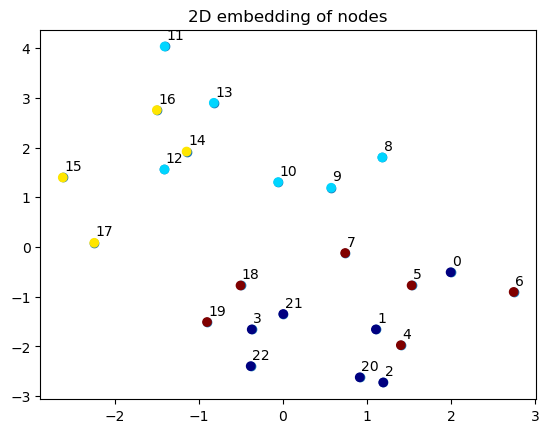

In [12]:
# Visualize the 2D coordinates of the node embeddings
x = my_network.node_embedding.weight.detach()
print(x,x.size())

# plot 2D coordinates
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(x[:,0], x[:,1])
idx = list(range(num_nodes))
ax.scatter(x[:,0], x[:,1], c=C, cmap='jet')
for i, txt in enumerate(idx):
    ax.annotate(txt, (x[:,0][i], x[:,1][i]), textcoords="offset points", xytext=(1,5))
ax.title.set_text('2D embedding of nodes')
plt.show()

### Question 2.3 : Compare visually the deepwalk embedding with the networkx visualization


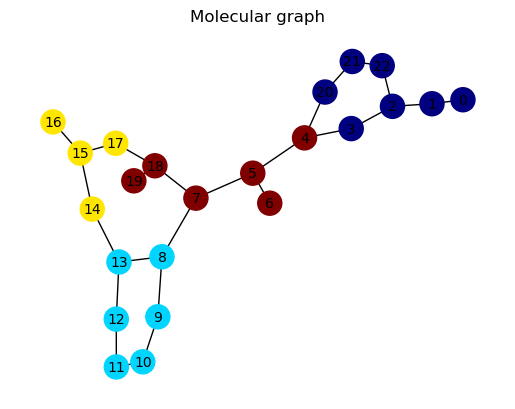

In [13]:
# Compare with graph edges
fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(A_nx, ax=ax, node_color=C, cmap='jet', with_labels=True, font_size=10) # visualise node indexes
ax.title.set_text('Molecular graph')
plt.show()